In [4]:
import numpy as np
import nibabel as nb
import matplotlib.pyplot as plt
import os

In [2]:
path = r'R:\C_PersonalData\Leon\qMRI_gradientcorrection\Data_Tianetal\sub_006\dwi'

In [6]:
dwi = nb.load(os.path.join(path, 'sub_006_dwi.nii.gz'))

In [15]:
dwi_img = dwi.get_fdata()

In [41]:
dwi_slice = dwi_img[:,:,82:84,:434]

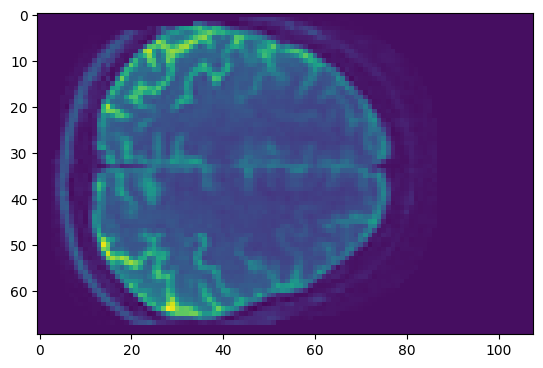

In [18]:
plt.imshow(dwi_slice[:,:,1,1])

In [19]:
dwi_slice.shape

(70, 108, 2, 850)

In [70]:
bvalues = np.loadtxt(os.path.join(path, 'sub_006_dwi.bval'))
bvecs = np.loadtxt(os.path.join(path, 'sub_006_dwi.bvec'))
deltas = np.loadtxt(os.path.join(path, 'sub_006_dwi.delta'))

bvalues = bvalues[:434]
bvecs = bvecs[:434]
deltas = deltas[:434]

## make a grad scheme
grad = np.zeros((len(bvalues),4))
grad[:,0:3] = bvecs
grad[:,3] = bvalues

np.savetxt(os.path.join(outpath,'grad.scheme'), grad, delimiter=' ')


In [61]:
#load mask 
dwi_mask = nb.load(os.path.join(path, 'sub_006_dwi_aparc+aseg.nii.gz'))
affine = dwi_mask.affine
dwi_mask = dwi_mask.get_fdata()
dwi_mask = dwi_mask[:,:,82:84]

In [65]:
mask = (dwi_mask >= 1) & (dwi_mask <=200)
dwi_mask[mask] = 1
dwi_mask[mask == False] = 0

In [66]:
nb.save(nb.Nifti1Image(dwi_mask, affine), os.path.join(outpath,'mask.nii'))

In [68]:
nb.save(nb.Nifti1Image(dwi_slice, affine), os.path.join(outpath,'dwi.nii'))

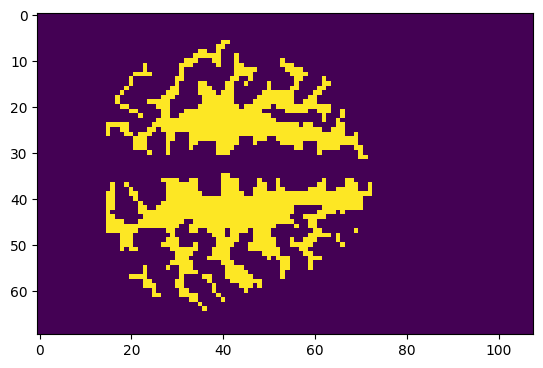

In [67]:
plt.imshow(dwi_mask[:,:,1])

In [57]:
outpath = r'C:\Users\garends3\Documents\Python_scripts\hackathon\microtorch\data'